# Fichero `adult.csv` — Preparación de datos y modelo supervisado

Este notebook reúne **todo lo trabajado** hasta ahora:
1. Carga del dataset `adult.csv`
2. Creación del **dataset reducido** (solo columnas objetivo)
3. Limpieza de valores ausentes (`?` → `NaN`) y eliminación de filas incompletas
4. Definición de **X** e **y** (objetivo: `income`)
5. Identificación de variables **numéricas** y **categóricas**
6. Preprocesado con **ColumnTransformer** (StandardScaler + OneHotEncoder)
7. División **train/test**
8. Entrenamiento de un **modelo** (Regresión Logística)
9. Evaluación básica (classification report + matriz de confusión)



## 1. Carga del dataset

Nos aseguramos de que `adult.csv` está en la misma carpeta que este notebook.

## 2. Creación del dataset reducido (solo columnas objetivo)
**Variables que se conservarán (las únicas permitidas en la práctica):**

Las variables que unicamente necesitaremos serian: age, workclass, education, education.num, occupation, race, sex, 
capital.gain, capital.loss, hours.per.week, income.

## 3. Limpieza del dataset reducido

En adult.csv, los valores ausentes a veces aparecen como `?` en algunas columnas, como podemos ver en la celda anterior
- Sustituimos `?` por `NaN`
- Comprobamos nulos por columna


In [85]:
import pandas as pd

df_adultos = pd.read_csv("../EjDatos/adult.csv")
df_adultos.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [86]:
df_filtrado = df_adultos[["age", "workclass", "education", "education.num", "occupation", "race", "sex", "capital.gain", "capital.loss", "hours.per.week", "income"]]
df_filtrado.head()

,age,workclass,education,education.num,occupation,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,?,HS-grad,9,?,White,Female,0,4356,40,<=50K
1,82,Private,HS-grad,9,Exec-managerial,White,Female,0,4356,18,<=50K
2,66,?,Some-college,10,?,Black,Female,0,4356,40,<=50K
3,54,Private,7th-8th,4,Machine-op-inspct,White,Female,0,3900,40,<=50K
4,41,Private,Some-college,10,Prof-specialty,White,Female,0,3900,40,<=50K


In [87]:
import numpy as np

df_filtrado.replace("?", np.nan, inplace=True)
df_filtrado.head()


/tmp/ipykernel_23699/2737496038.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado.replace("?", np.nan, inplace=True)


,age,workclass,education,education.num,occupation,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,NaN,HS-grad,9,NaN,White,Female,0,4356,40,<=50K
1,82,Private,HS-grad,9,Exec-managerial,White,Female,0,4356,18,<=50K
2,66,NaN,Some-college,10,NaN,Black,Female,0,4356,40,<=50K
3,54,Private,7th-8th,4,Machine-op-inspct,White,Female,0,3900,40,<=50K
4,41,Private,Some-college,10,Prof-specialty,White,Female,0,3900,40,<=50K


## 4. Definir el problema supervisado: predicción de salario (`income`)

Averiguar las personas que cobran mas de 50k o menos.

## 5. Identificación de variables numéricas y categóricas

De lo anterior vemos que hay:
- variables numéricas: age, education.num, sapital.gain, capital.loss, hours.per.week, income.
- variables categóricas: workclass, education, occupation, race, sex.

### Preprocesado de los datos

En esta fase se preparan las variables para su uso en el modelo de Machine Learning.
Dado que el conjunto de datos contiene variables numéricas y categóricas, se aplican
técnicas de preprocesado diferenciadas, incluyendo la imputación de valores nulos,
el escalado de variables numéricas y la codificación de variables categóricas mediante
One-Hot Encoding.


## 6. Preprocesado con sklearn

Ahora terminamos de preparar todo

In [88]:
df_filtrado_income = df_filtrado.copy()

df_filtrado_income["income"].replace({
    ">50K": 1,
    "<=50K": 0
}, inplace=True)

df_filtrado_income.head()

/tmp/ipykernel_23699/734793899.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filtrado_income["income"].replace({
/tmp/ipykernel_23699/734793899.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_filtrado_income["income"].replace({


,age,workclass,education,education.num,occupation,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,NaN,HS-grad,9,NaN,White,Female,0,4356,40,0
1,82,Private,HS-grad,9,Exec-managerial,White,Female,0,4356,18,0
2,66,NaN,Some-college,10,NaN,Black,Female,0,4356,40,0
3,54,Private,7th-8th,4,Machine-op-inspct,White,Female,0,3900,40,0
4,41,Private,Some-college,10,Prof-specialty,White,Female,0,3900,40,0


In [89]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = df_filtrado_income[["age", "capital.gain", "capital.loss", "hours.per.week"]]
y = df_filtrado_income["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

## 7. División en entrenamiento y prueba

### Entrenamiento del modelo

Una vez definidos el conjunto de entrenamiento y el preprocesado de los datos,
se procede al entrenamiento de un modelo de clasificación basado en regresión logística,
utilizado como modelo base para este problema.


In [90]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

## 8. Regresión


### Evaluación del modelo

El rendimiento del modelo se evalúa utilizando distintas métricas de clasificación,
así como la matriz de confusión, con el objetivo de analizar su capacidad predictiva
y detectar posibles limitaciones.


In [91]:
y_pred = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2: ", r2)
print("MAE: ", mae)
print("MSE: ", mse)



R2:  0.14643678061632615
MAE:  0.31834125525743545
MSE:  0.15389615720493982


In [92]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred.round())
cm


array([[4859,  117,    0],
       [1340,  187,   10],
       [   0,    0,    0]])

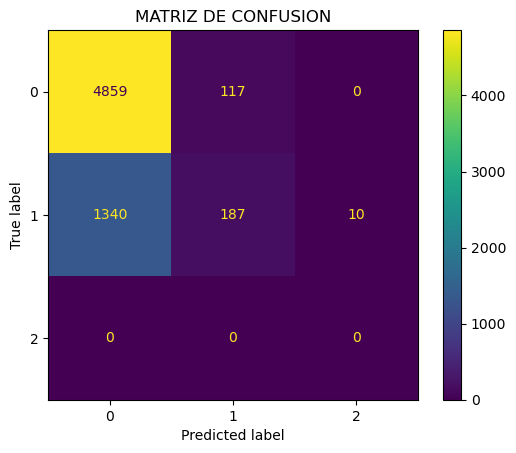

In [93]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("MATRIZ DE CONFUSION")
plt.show()

In [94]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [96]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

In [97]:
# Porcentaje de predicciones que hace bien
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.7971748810072163


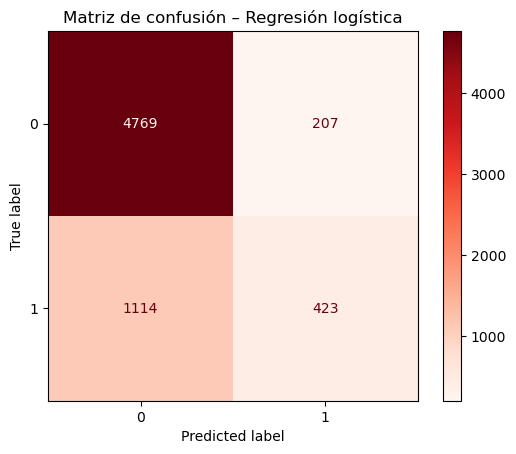

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
)
disp.plot(cmap="Reds")
plt.title("Matriz de confusión – Regresión logística")
plt.show()


## 9. Evaluación del modelo
